# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

# Data Loading (df_old, df_new)

In [2]:
url_old = 'https://drive.google.com/uc?id=1DYnW-YW49a3YRwLZ6oxhdG3HEZlL0fVu'
url_new = 'https://drive.google.com/uc?id=1s5JOuNutZdcNxbCroj7lDLWTQWuEPFxE'

df_old = pd.read_csv(url_old)
df_new = pd.read_csv(url_new)

# Data Wrangling (missed invalid profit case)
masih ada 6 record di mana Revenue==0, tapi profit positif. Ini terjadi krn ada miss dibagian invalid profit, harusnya profit dikatakan tidak valid ketika ((Profit>Revenue) & Revenue>=0), atau simplenya hanya (Profit>Revenue) saja. Karena kondisi pengecekan yang terlalu spesifik seperti yang sebelumnya, masih ditemukan 109 record data invalid yang memenuhi kondisi (Profit>Revenue_recalc). Karena data yang memenuhi kedua kondisi ini tidak sesuai dengan business logic, maka dilakukan drop.

In [3]:
df_new_cleaned = df_new.copy()

In [4]:
df_new_cleaned.shape

(2115, 21)

In [5]:
mask_invalid_final=(df_new_cleaned['Revenue_recalc']==0)&(df_new_cleaned['Profit']>0)&(df_new_cleaned['Units_Sold']>0)
df_new_cleaned=df_new_cleaned[~mask_invalid_final]

In [6]:
mask_invalid_profit2=(df_new_cleaned['Profit']>df_new_cleaned['Revenue_recalc'])
df_new_cleaned = df_new_cleaned[~mask_invalid_profit2]

In [7]:
df_final = df_new_cleaned.copy()

In [8]:
df_final.shape

(2000, 21)

In [9]:
df_final.to_csv('df_final.csv', index=False, float_format='%.2f')

# Review & Evaluation of Data Quality

Melihat perbandingan missing values pada dataset sebelum cleaning dan setelah cleaning

In [10]:
missing_before = df_old.isna().sum().sum()
missing_after = df_final.isna().sum().sum()

print("Missing Values Before Cleaning:", missing_before)
print("Missing Values After  Cleaning:", missing_after)

Missing Values Before Cleaning: 5283
Missing Values After  Cleaning: 0


In [11]:
print("Summary Missing Values Dataset Before Cleaning")
pd.DataFrame({
    'Missing_value' :df_old.isnull().sum(),
    'Missing_value_percentage' : df_old.isnull().sum() / len(df_old) * 100
})

Summary Missing Values Dataset Before Cleaning
Summary Missing Values Dataset Before Cleaning


,Missing_value,Missing_value_percentage
Order_ID,0,0.00
Gender_Category,0,0.00
Product_Line,0,0.00
Product_Name,0,0.00
Size,510,20.40
Units_Sold,1235,49.40
MRP,1254,50.16
Discount_Applied,1668,66.72
Revenue,0,0.00
Order_Date,616,24.64


,Missing_value,Missing_value_percentage
Order_ID,0,0.00
Gender_Category,0,0.00
Product_Line,0,0.00
Product_Name,0,0.00
Size,510,20.40
Units_Sold,1235,49.40
MRP,1254,50.16
Discount_Applied,1668,66.72
Revenue,0,0.00
Order_Date,616,24.64


In [12]:
print("Summary Missing Values Dataset After Cleaning")
pd.DataFrame({
    'Missing_value' :df_final.isnull().sum(),
    'Missing_value_percentage' : df_final.isnull().sum() / len(df_final) * 100
})

Summary Missing Values Dataset After Cleaning


,Missing_value,Missing_value_percentage
Order_ID,0,0.0
Gender_Category,0,0.0
Product_Line,0,0.0
Product_Name,0,0.0
Size,0,0.0
Units_Sold,0,0.0
MRP,0,0.0
Discount_Applied,0,0.0
Revenue,0,0.0
Order_Date,0,0.0


Melihat perbandingan negative value dan invalid discount pada dataset sebelum cleaning dan setelah cleaning

In [13]:
print("Summary Negative Value & Invalid Discount Before Cleaning")
print("Neg Units:",(df_old['Units_Sold']<0).sum())
print("Neg Revenue:",(df_old['Revenue']<0).sum())
print("Neg Profit:",(df_old['Profit']<0).sum())
print("Discount > 1:",(df_old['Discount_Applied']>1).sum())

Summary Negative Value & Invalid Discount Before Cleaning
Neg Units: 205
Neg Revenue: 53
Neg Profit: 578
Discount > 1: 180


In [14]:
print("Summary Negative Value & Invalid Discount After Cleaning")
print("Neg Units:",(df_final['Units_Sold']<0).sum())
print("Neg Revenue_recalc:",(df_final['Revenue_recalc']<0).sum())
print("Neg Profit:",(df_final['Profit']<0).sum())
print("Discount > 1:",(df_final['Discount_Applied']>1).sum())

Summary Negative Value & Invalid Discount After Cleaning
Neg Units: 0
Neg Revenue_recalc: 0
Neg Profit: 483
Discount > 1: 0


Melihat perbandingan tipe data pada dataset sebelum cleaning dan setelah cleaning

In [15]:
df_old.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Gender_Category   2500 non-null   object 
 2   Product_Line      2500 non-null   object 
 3   Product_Name      2500 non-null   object 
 4   Size              1990 non-null   object 
 5   Units_Sold        1265 non-null   float64
 6   MRP               1246 non-null   float64
 7   Discount_Applied  832 non-null    float64
 8   Revenue           2500 non-null   float64
 9   Order_Date        1884 non-null   object 
 10  Sales_Channel     2500 non-null   object 
 11  Region            2500 non-null   object 
 12  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), object(7)
memory usage: 254.0+ KB


In [16]:
df_final['Order_Date'] = pd.to_datetime(df_final['Order_Date'], errors='coerce', format='mixed')
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 2114
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2000 non-null   int64         
 1   Gender_Category   2000 non-null   object        
 2   Product_Line      2000 non-null   object        
 3   Product_Name      2000 non-null   object        
 4   Size              2000 non-null   object        
 5   Units_Sold        2000 non-null   int64         
 6   MRP               2000 non-null   float64       
 7   Discount_Applied  2000 non-null   float64       
 8   Revenue           2000 non-null   float64       
 9   Order_Date        2000 non-null   datetime64[ns]
 10  Sales_Channel     2000 non-null   object        
 11  Region            2000 non-null   object        
 12  Profit            2000 non-null   float64       
 13  Revenue_recalc    2000 non-null   float64       
 14  is_return         2000 non-nu

Melihat perbandingan konsistensi data Region pada dataset sebelum cleaning dan setelah cleaning

In [17]:
print(f"Inconsistent Region: {df_old['Region'].unique()}")

Inconsistent Region: ['bengaluru' 'Hyd' 'Mumbai' 'Pune' 'Delhi' 'Bangalore' 'Hyderabad'
 'hyderbad' 'Kolkata']


In [18]:
print(f"Consistent Region: {df_final['Region'].unique()}")

Consistent Region: ['Bangalore' 'Hyderabad' 'Mumbai' 'Pune' 'Delhi' 'Kolkata']


Melihat perbandingan invalid case pada dataset sebelum cleaning dan setelah cleaning

In [19]:
#invalid units_sold
mask_invalid_units=(df_old['Units_Sold']==0)&(df_old['Revenue']==0)&(df_old['Profit']!=0)

#invalid revenue (negatif tapi units positif)
mask_invalid_revenue=(df_old['Revenue']<0)&(df_old['Units_Sold']>0)

#invalid discount
mask_invalid_discount=(df_old['Discount_Applied']>1)

#invalid profit
mask_invalid_profit=(df_old['Profit']>df_old['Revenue'])&(df_old['Revenue']>0)

print("Summary Anomalies Case Before Cleaning")
print("Invalid Units:",mask_invalid_units.sum())
print("Invalid Revenue:",mask_invalid_revenue.sum())
print("Invalid Discount:",mask_invalid_discount.sum())
print("Invalid Profit:",mask_invalid_profit.sum())

Summary Anomalies Case Before Cleaning
Invalid Units: 224
Invalid Revenue: 30
Invalid Discount: 180
Invalid Profit: 10


In [20]:
#invalid units_sold
mask_invalid_units=(df_final['Units_Sold']==0)&(df_final['Revenue_recalc']==0)&(df_final['Profit']!=0)

#invalid revenue (negatif tapi units positif)
mask_invalid_revenue=(df_final['Revenue_recalc']<0)&(df_final['Units_Sold']>0)

#invalid discount
mask_invalid_discount=(df_final['Discount_Applied']>1)

#invalid profit
mask_invalid_profit=(df_final['Profit']>df_final['Revenue_recalc'])&(df_final['Revenue_recalc']>0)

print("Summary Anomalies Case After Cleaning")
print("Invalid Units:",mask_invalid_units.sum())
print("Invalid Revenue:",mask_invalid_revenue.sum())
print("Invalid Discount:",mask_invalid_discount.sum())
print("Invalid Profit:",mask_invalid_profit.sum())

Summary Anomalies Case After Cleaning
Invalid Units: 0
Invalid Revenue: 0
Invalid Discount: 0
Invalid Profit: 0


In [21]:
df_final.shape

(2000, 21)

Melihat perbandingan outlier data pada dataset sebelum cleaning dan setelah cleaning

In [22]:
def count_outliers(df):
    numeric_cols = df.select_dtypes(include=np.number)

    outlier_count = {}

    for col in numeric_cols.columns:
        Q1 = numeric_cols[col].quantile(0.25)
        Q3 = numeric_cols[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = ((numeric_cols[col] < lower) |
                    (numeric_cols[col] > upper)).sum()

        outlier_count[col] = outliers

    return pd.Series(outlier_count)

In [23]:
print("\nOutliers Before Cleaning")
print(count_outliers(df_old))

print("\nOutliers After Cleaning")
print(count_outliers(df_final))


Outliers Before Cleaning
Order_ID              0
Units_Sold            0
MRP                   0
Discount_Applied      0
Revenue             166
Profit                0
dtype: int64

Outliers After Cleaning
Order_ID              0
Units_Sold            0
MRP                   0
Discount_Applied    458
Revenue             135
Profit                0
Revenue_recalc       29
year                  0
month                 0
day                   0
profit_margin       118
revenue_per_unit      5
dtype: int64


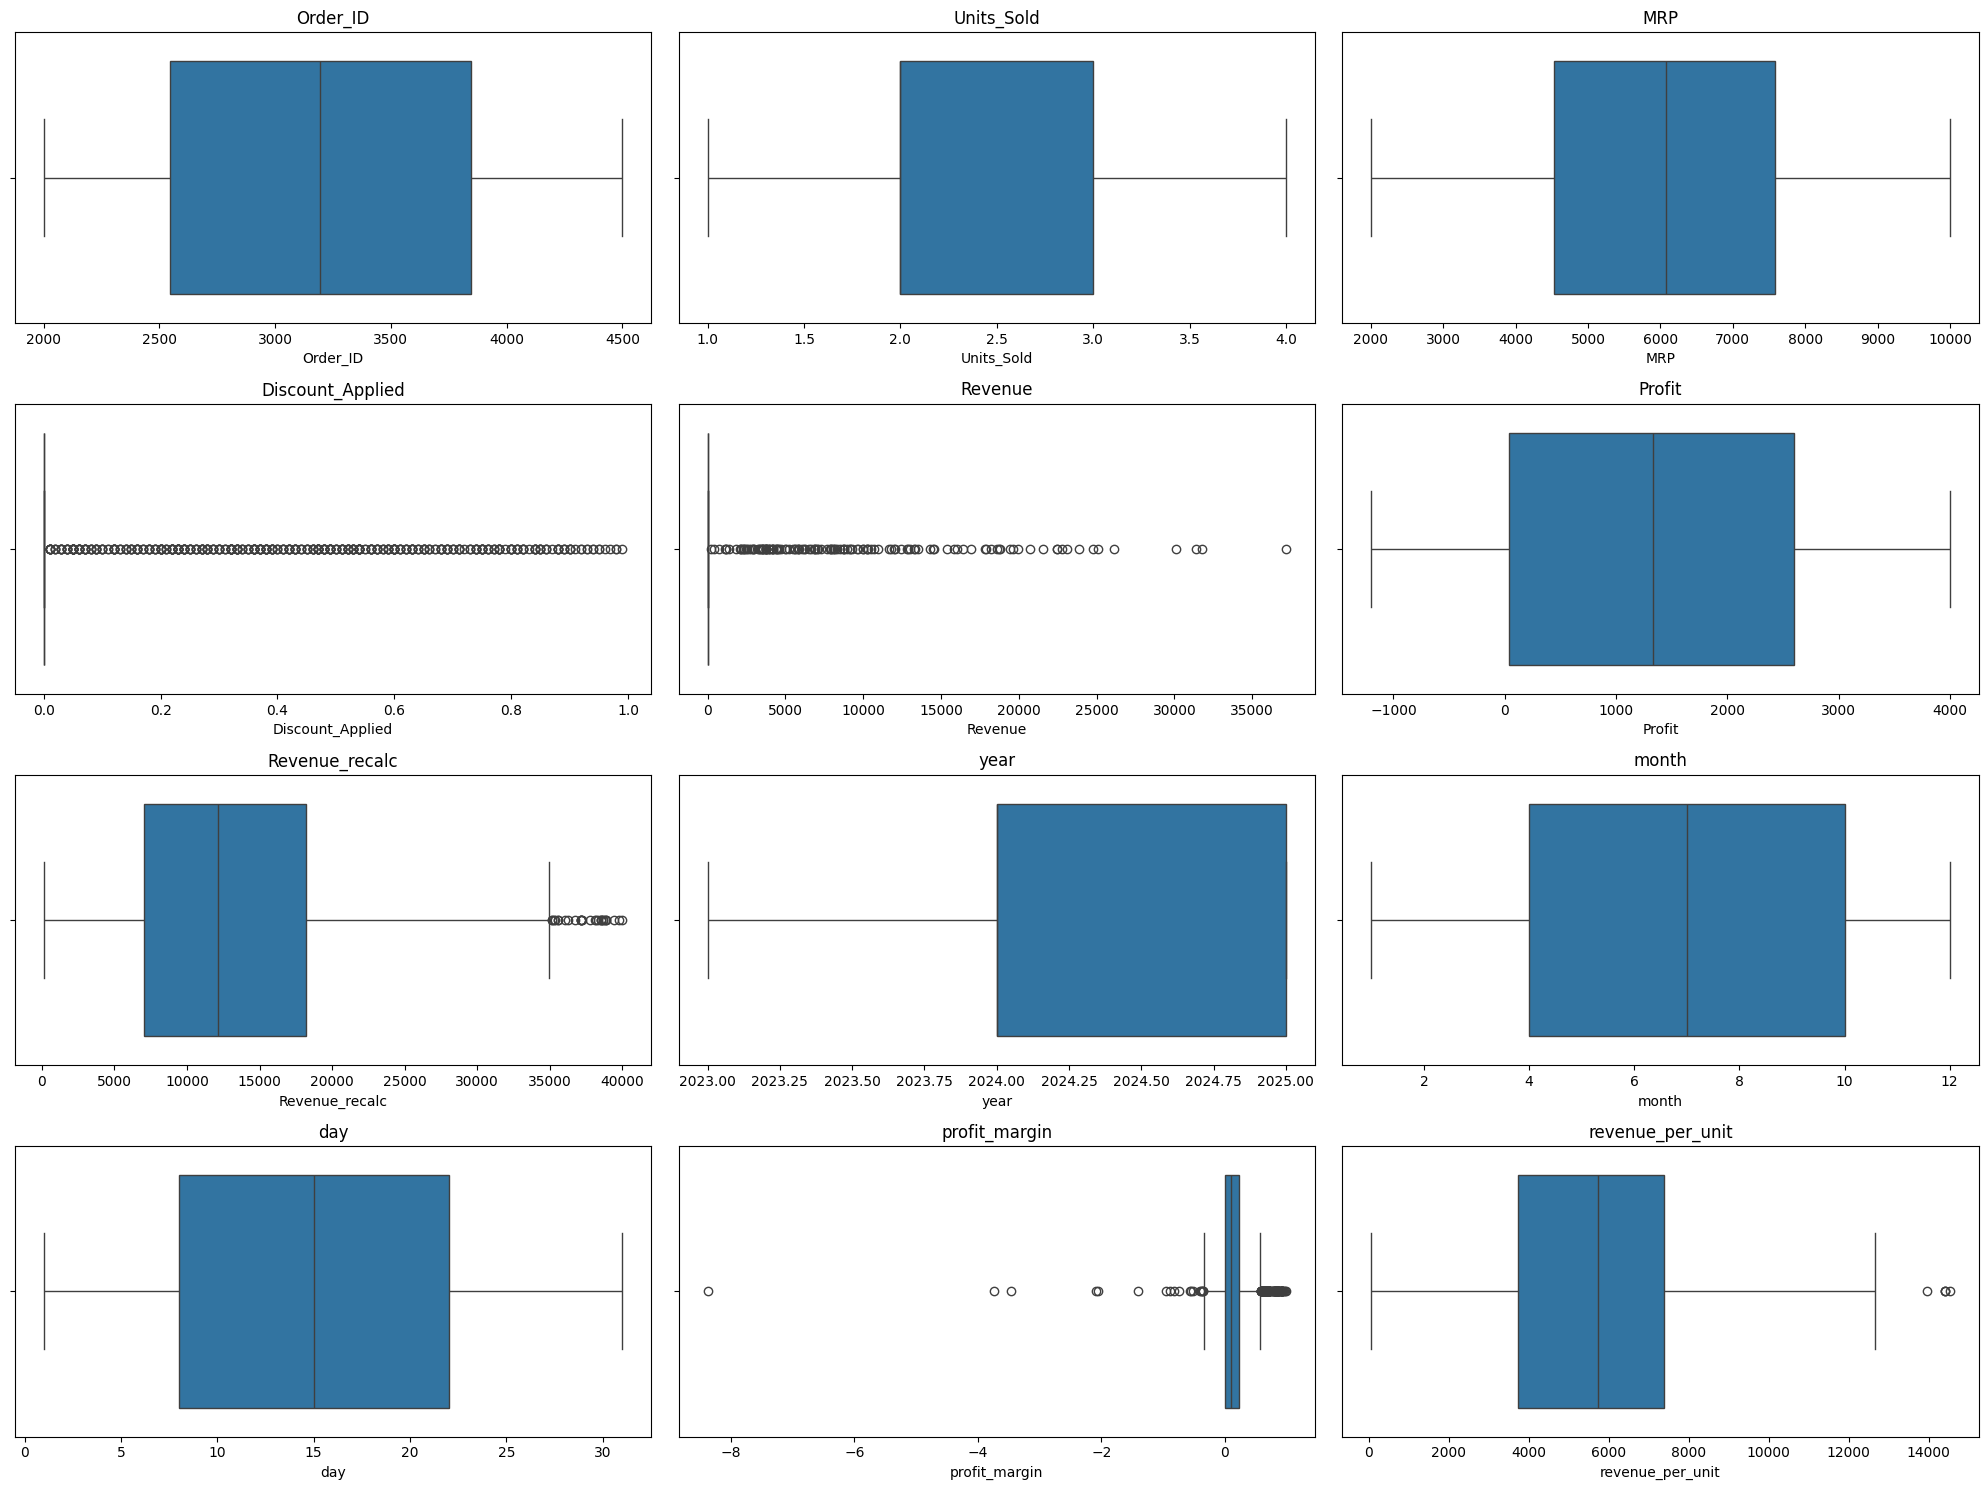

In [24]:
def visual_numerical(df, numCols):
    n = len(numCols)
    rows = -(-n//3)
    plt.figure(figsize=(20, 15))

    for i, col in enumerate(numCols, 1):
      plt.subplot(rows, 3, i)
      sns.boxplot(x=df[col])
      plt.title(col)

    plt.tight_layout()
    plt.show()

numerical_col = df_final.select_dtypes(include=['int64','float64', 'int32']).columns.tolist()
visual_numerical(df_final, numerical_col)

Melihat perbandingan data yang dihapus dengan data yang tidak di hapus

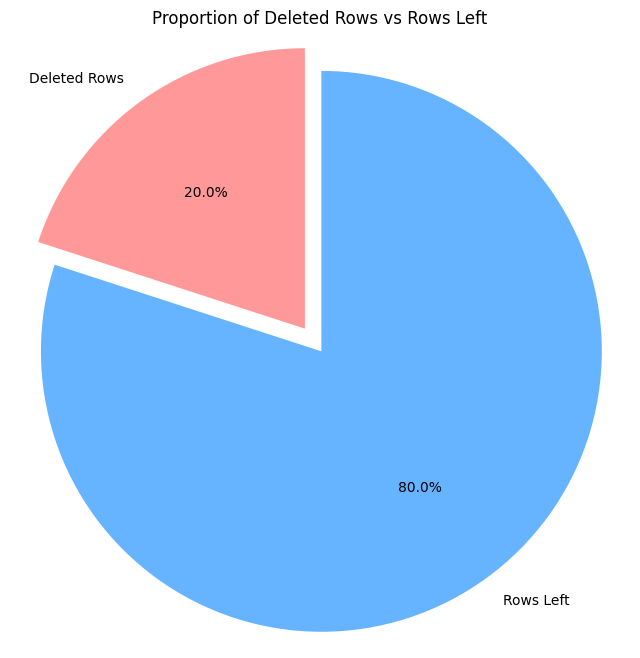

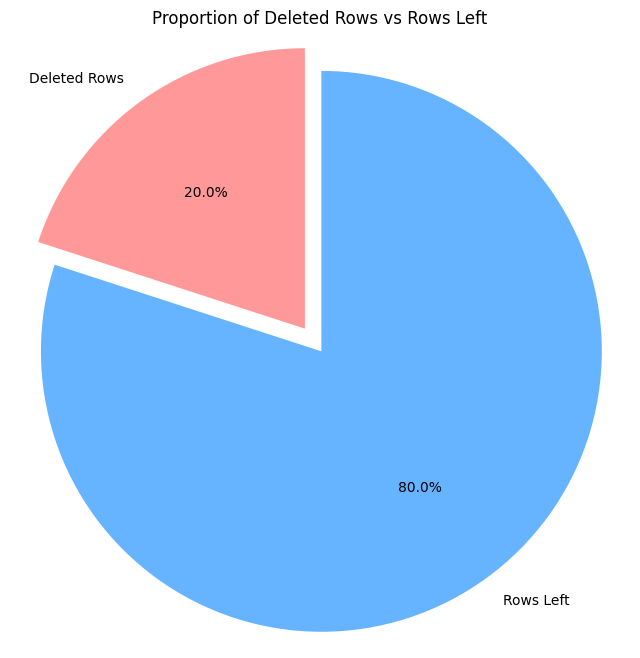

In [25]:
sum_delete = len(df_old) - len(df_final)
sum_not_delete = len(df_final)

labels = ['Deleted Rows', 'Rows Left']
sizes = [sum_delete, sum_not_delete]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # Explode the 'Quantity Null' slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Proportion of Deleted Rows vs Rows Left')
plt.show()

In [26]:
df_final.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_ID,2000.0,3201.8375,2000.0,2544.75,3191.5,3847.25,4499.0,747.186084
Units_Sold,2000.0,2.4265,1.0,2.0,2.0,3.0,4.0,0.985436
MRP,2000.0,6070.552025,2006.63,4535.145,6077.13,7577.155,9996.22,2006.691371
Discount_Applied,2000.0,0.100245,0.0,0.0,0.0,0.0,0.99,0.222022
Revenue,2000.0,649.517935,0.0,0.0,0.0,0.0,37169.35,3101.060285
Order_Date,2000,2024-11-09 14:52:48,2023-07-26 00:00:00,2024-08-10 00:00:00,2024-11-20 00:00:00,2025-03-26 00:00:00,2025-12-07 00:00:00,NaN
Profit,2000.0,1334.351845,-1199.32,38.9425,1333.485,2604.4325,3999.21,1481.708911
Revenue_recalc,2000.0,13411.017035,136.57,7038.04,12154.26,18231.39,39984.88,7992.899515
year,2000.0,2024.343,2023.0,2024.0,2024.0,2025.0,2025.0,0.56081
month,2000.0,6.726,1.0,4.0,7.0,10.0,12.0,3.516832


# Advanced Pattern, Trend, and Relationship Analysis

In [27]:
df_analysis = df_final.copy()

In [28]:
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 2114
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          2000 non-null   int64         
 1   Gender_Category   2000 non-null   object        
 2   Product_Line      2000 non-null   object        
 3   Product_Name      2000 non-null   object        
 4   Size              2000 non-null   object        
 5   Units_Sold        2000 non-null   int64         
 6   MRP               2000 non-null   float64       
 7   Discount_Applied  2000 non-null   float64       
 8   Revenue           2000 non-null   float64       
 9   Order_Date        2000 non-null   datetime64[ns]
 10  Sales_Channel     2000 non-null   object        
 11  Region            2000 non-null   object        
 12  Profit            2000 non-null   float64       
 13  Revenue_recalc    2000 non-null   float64       
 14  is_return         2000 non-nu

## Examining Deeper or More Specific Relationships Between Variables

### Subgroup Comparison

1. Sales Channel Distribution

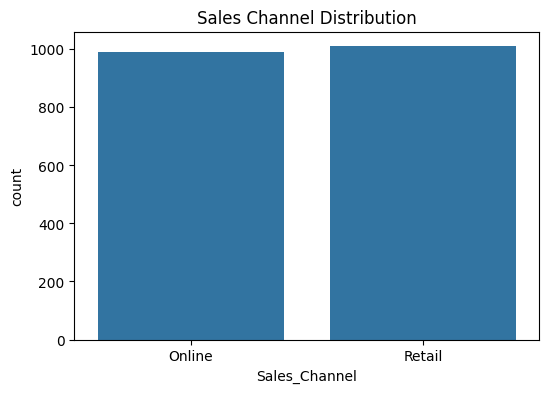

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_analysis,x='Sales_Channel')
plt.title('Sales Channel Distribution')
plt.show()

2. Gender vs Sales Channel

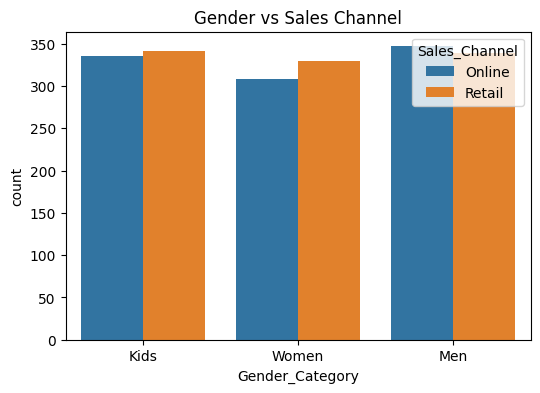

Sales_Channel,Online,Retail
Gender_Category,,
Kids,49.556213,50.443787
Men,50.583090,49.416910
Women,48.275862,51.724138


In [30]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_analysis,x='Gender_Category',hue='Sales_Channel')
plt.title('Gender vs Sales Channel')
plt.show()

pd.crosstab(df_analysis['Gender_Category'],df_analysis['Sales_Channel'],normalize='index')*100

3. Product Line vs Sales Channel

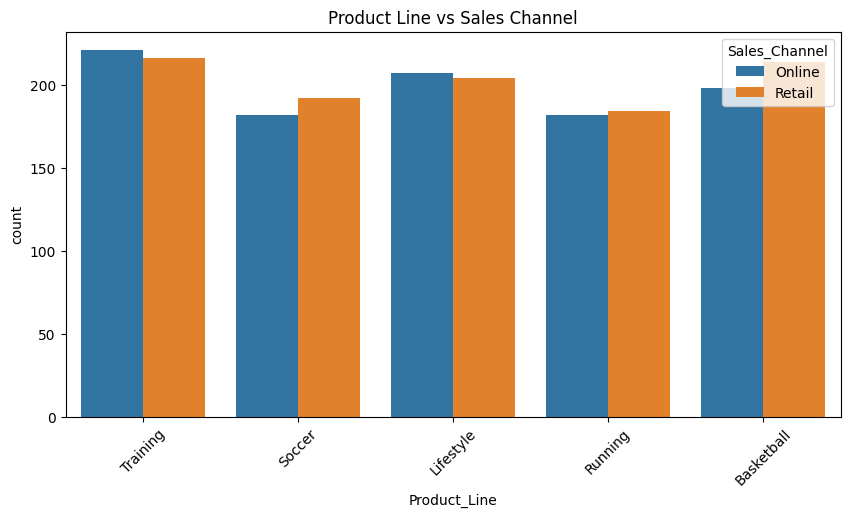

Sales_Channel,Online,Retail
Product_Line,,
Basketball,48.058252,51.941748
Lifestyle,50.364964,49.635036
Running,49.726776,50.273224
Soccer,48.663102,51.336898
Training,50.572082,49.427918


In [31]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_analysis,x='Product_Line',hue='Sales_Channel')
plt.xticks(rotation=45)
plt.title('Product Line vs Sales Channel')
plt.show()

pd.crosstab(df_analysis['Product_Line'],df_analysis['Sales_Channel'],normalize='index')*100

4. Region vs Sales Channel

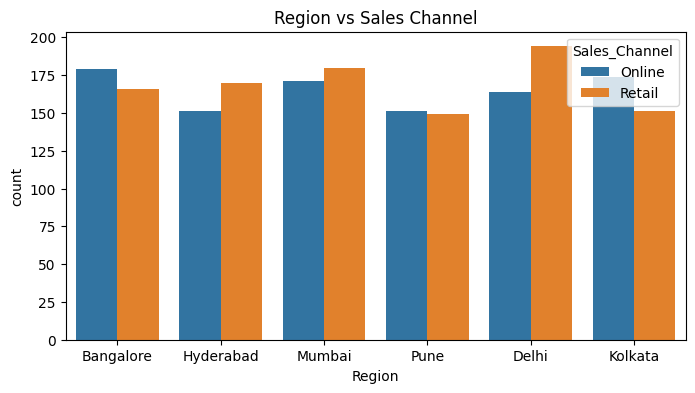

Sales_Channel,Online,Retail
Region,,
Bangalore,51.884058,48.115942
Delhi,45.810056,54.189944
Hyderabad,47.040498,52.959502
Kolkata,53.538462,46.461538
Mumbai,48.717949,51.282051
Pune,50.333333,49.666667


In [32]:
plt.figure(figsize=(8,4))
sns.countplot(data=df_analysis,x='Region',hue='Sales_Channel')
plt.title('Region vs Sales Channel')
plt.show()

pd.crosstab(df_analysis['Region'],df_analysis['Sales_Channel'],normalize='index')*100

### Time-based Trend

In [33]:
df_analysis['Order_Date']=pd.to_datetime(df_analysis['Order_Date'])

df_analysis['year_month']=df_analysis['Order_Date'].dt.to_period('M').astype(str)

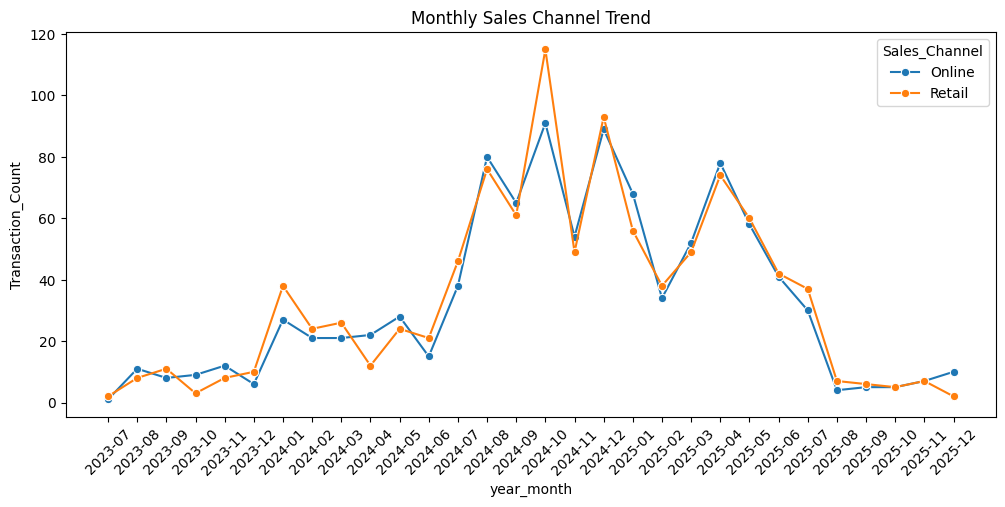

In [34]:
monthly_channel=df_analysis.groupby(['year_month','Sales_Channel']).size().reset_index(name='Transaction_Count')

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_channel,x='year_month',y='Transaction_Count',hue='Sales_Channel',marker='o')

plt.xticks(rotation=45)
plt.title('Monthly Sales Channel Trend')
plt.show()

## Hypothesis Testing

In [35]:
def compare_online_vs_retail(df,column):
    online=df[df["Sales_Channel"]=="Online"][column].dropna()
    retail=df[df["Sales_Channel"]=="Retail"][column].dropna()

    print("="*60)
    print(column.upper())
    print("="*60)

    print(f"Online Sample Size: {len(online)}")
    print(f"Retail Sample Size: {len(retail)}")
    print()

    print(f"Online Mean: {online.mean():.2f}")
    print(f"Retail Mean: {retail.mean():.2f}")
    print()

    p_online=shapiro(online.sample(min(len(online),500),random_state=42)).pvalue
    p_retail=shapiro(retail.sample(min(len(retail),500),random_state=42)).pvalue

    print("Normality Test (Shapiro-Wilk)")
    print(f"Online p-value: {p_online:.4f}")
    print(f"Retail p-value: {p_retail:.4f}")
    print()

    if p_online>0.05 and p_retail>0.05:
        p_var=levene(online,retail).pvalue
        stat,p=ttest_ind(
            online,
            retail,
            equal_var=p_var>0.05
        )
        print("Data is normally distributed.")
        print("Test Used: Independent T-Test")

    else:
        stat,p=mannwhitneyu(
            online,
            retail,
            alternative='two-sided'
        )
        print("Data is not normally distributed.")
        print("Test Used: Mann-Whitney U Test")
    print(f"P-value: {p:.4f}")

    if p<0.05:
      print("Conclusion: There is a statistically significant difference between Online and Retail.")
    else:
      print("Conclusion: There is no statistically significant difference between Online and Retail.")

### Revenue Distribution by Sales Channel

In [36]:
compare_online_vs_retail(df_analysis,"Revenue_recalc")

REVENUE_RECALC
Online Sample Size: 990
Retail Sample Size: 1010

Online Mean: 13936.23
Retail Mean: 12896.21

Normality Test (Shapiro-Wilk)
Online p-value: 0.0000
Retail p-value: 0.0000

Data is not normally distributed.
Test Used: Mann-Whitney U Test
P-value: 0.0121
Conclusion: There is a statistically significant difference between Online and Retail.


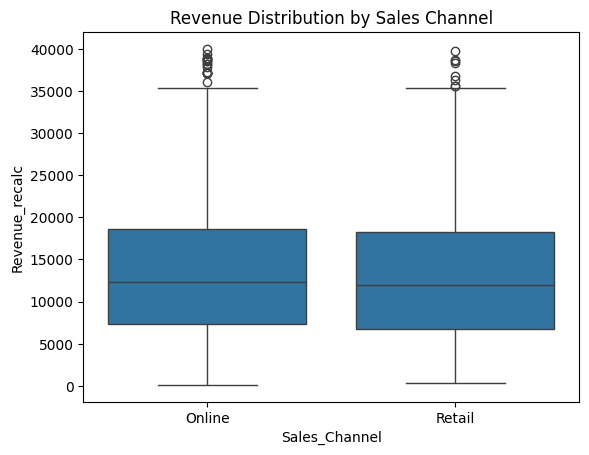

In [37]:
sns.boxplot(
    data=df_analysis,
    x="Sales_Channel",
    y="Revenue_recalc"
)

plt.title("Revenue Distribution by Sales Channel")
plt.show()

### Profit Distribution by Sales Channel

In [38]:
compare_online_vs_retail(df_analysis,"Profit")

PROFIT
Online Sample Size: 990
Retail Sample Size: 1010

Online Mean: 1317.47
Retail Mean: 1350.90

Normality Test (Shapiro-Wilk)
Online p-value: 0.0000
Retail p-value: 0.0000

Data is not normally distributed.
Test Used: Mann-Whitney U Test
P-value: 0.5959
Conclusion: There is no statistically significant difference between Online and Retail.


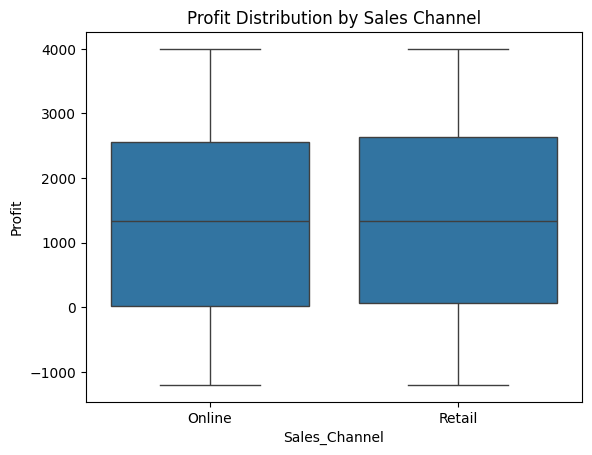

In [39]:
sns.boxplot(
    data=df_analysis,
    x="Sales_Channel",
    y="Profit"
)

plt.title("Profit Distribution by Sales Channel")
plt.show()

## Simulated A/B Testing

No Discount (control) VS Discounted Transaction (treatment)

In [40]:
def simulated_ab_test(df):
    median_discount=df["Discount_Applied"].median()
    group_a=df[df["Discount_Applied"]<=median_discount]["Revenue_recalc"]
    group_b=df[df["Discount_Applied"]>median_discount]["Revenue_recalc"]

    print("="*60)
    print("SIMULATED A/B TEST")
    print("="*60)

    print(f"Median Discount: {median_discount:.2f}")

    print(f"No Discount Transactions: {len(group_a)}")
    print(f"Discounted Transaction: {len(group_b)}")
    print()

    print(f"Mean Revenue (No Discount): {group_a.mean():.2f}")
    print(f"Mean Revenue (Discounted): {group_b.mean():.2f}")
    print()

    stat,p=ttest_ind(
        group_a,
        group_b,
        equal_var=False
    )
    print(f"P-value: {p:.4f}")

    if p<0.05:
      print("Conclusion: There is a statistically significant difference between No Discount and Discounted transactions.")
    else:
      print("Conclusion: There is no statistically significant difference between No Discount and Discounted transactions.")

In [41]:
simulated_ab_test(df_analysis)

SIMULATED A/B TEST
Median Discount: 0.00
No Discount Transactions: 1542
Discounted Transaction: 458

Mean Revenue (No Discount): 14992.45
Mean Revenue (Discounted): 8086.63

P-value: 0.0000
Conclusion: There is a statistically significant difference between No Discount and Discounted transactions.


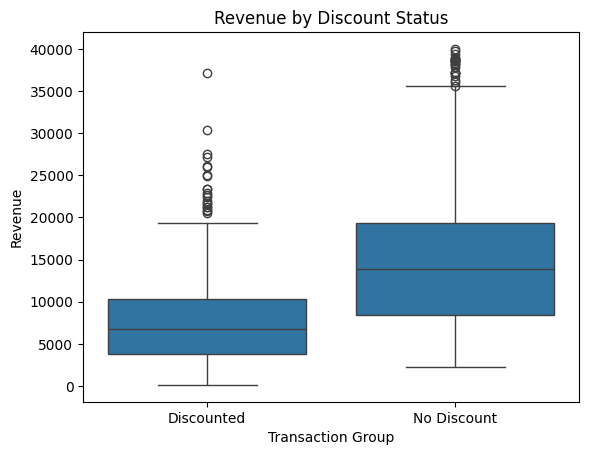

In [42]:
discount_group=np.where(
    df_analysis["Discount_Applied"]<=df_analysis["Discount_Applied"].median(),
    "No Discount",
    "Discounted"
)

sns.boxplot(
    x=discount_group,
    y=df_analysis["Revenue_recalc"]
)

plt.title("Revenue by Discount Status")
plt.xlabel("Transaction Group")
plt.ylabel("Revenue")
plt.show()

## Identifying the Most Influential variabes Related to the Problem Context

### All Features

In [43]:
all_featuresClass=[
    # 'Order_ID', #tidak seharusnya punya importance
    'Gender_Category',
    'Product_Line',
    'Product_Name',
    'Size',
    'Units_Sold',
    'MRP',
    'Discount_Applied',
    # 'Revenue', #zero inflated
    # 'Order_Date', #sudah ada variable turunan
    'Region',
    # 'Sales_Channel' #target klasifikasi
    'Profit',
    'Revenue_recalc',
    # 'year', #variasi sedikit (kurang informatif)
    'month',
    # 'day', #granularity terlalu spesifik
    'day_of_week'
    # 'profit_margin', #sudah ada feature Profit dan Revenue_recalc
    # 'revenue_per_unit' #sudah ada feature Revenue_recalc dan Units_Sold
]

In [44]:
X=df_analysis[all_featuresClass]
y=df_analysis['Sales_Channel']

### Splitting

In [45]:
#train test split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Encoding

In [46]:
#encode target
le=LabelEncoder()
y=le.fit_transform(y)

In [47]:
print(le.classes_)

['Online' 'Retail']


In [48]:
#encode cat features
X_train=pd.get_dummies(X_train,drop_first=True)
X_test=pd.get_dummies(X_test,drop_first=True)

In [49]:
X_train,X_test=X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

### Scaling

In [50]:
num_cols=[
    'Units_Sold',
    'MRP',
    'Discount_Applied',
    'Profit',
    'Revenue_recalc',
    'month'
]

scaler=StandardScaler()

X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

## Random Forest Feature Importance

In [51]:
rf_fs=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_fs.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [52]:
importance_df=pd.DataFrame({
    'Feature':X_train.columns,
    'Importance':rf_fs.feature_importances_
})

importance_df=importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(10))

                  Feature  Importance
1                     MRP    0.127230
4          Revenue_recalc    0.122359
3                  Profit    0.118682
5                   month    0.074549
0              Units_Sold    0.046794
2        Discount_Applied    0.042155
31                 Size_M    0.022207
6     Gender_Category_Men    0.021331
7   Gender_Category_Women    0.020367
33                Size_XL    0.019472


In [53]:
top_features_rf=importance_df.head(10)['Feature']

print(top_features_rf)

1                       MRP
4            Revenue_recalc
3                    Profit
5                     month
0                Units_Sold
2          Discount_Applied
31                   Size_M
6       Gender_Category_Men
7     Gender_Category_Women
33                  Size_XL
Name: Feature, dtype: object


## Recursive Feature Elimination

In [54]:
rfe_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rfe=RFE(
    estimator=rfe_model,
    n_features_to_select=10
)

rfe.fit(X_train,y_train)

RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=10)

In [55]:
selected_features_rfe=X_train.columns[
    rfe.support_
]

print(selected_features_rfe)

Index(['Units_Sold', 'MRP', 'Discount_Applied', 'Profit', 'Revenue_recalc',
       'month', 'Gender_Category_Men', 'Product_Line_Training', 'Size_M',
       'Region_Mumbai'],
      dtype='object')


### Selected Features (Final)

In [56]:
X_train_selected=X_train[selected_features_rfe]
X_test_selected=X_test[selected_features_rfe]

# Evaluation of Analytical Methods and Metrics

Random Forest

In [57]:
final_model_before = RandomForestClassifier(random_state=42)
final_model_before.fit(X_train, y_train)

train_acc_before = final_model_before.score(X_train, y_train)
test_acc_before = final_model_before.score(X_test, y_test)

y_pred_before = final_model_before.predict(X_test)
y_prob_before = final_model_before.predict_proba(X_test)[:, 1]

final_model_after = RandomForestClassifier(random_state=42)
final_model_after.fit(X_train_selected, y_train)

train_acc_after = final_model_after.score(X_train_selected, y_train)
test_acc_after = final_model_after.score(X_test_selected, y_test)

y_pred_after = final_model_after.predict(X_test_selected)
y_prob_after = final_model_after.predict_proba(X_test_selected)[:, 1]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_before = RandomForestClassifier(random_state=42)
rf_cv_scores_before = cross_val_score(rf_before, X_train, y_train, cv=kf, scoring='accuracy')

rf_after = RandomForestClassifier(random_state=42)
rf_cv_scores_after = cross_val_score(rf_after, X_train_selected, y_train, cv=kf, scoring='accuracy')

In [58]:
print("=== BEFORE FEATURE SELECTION ===")
print(f"Training Accuracy: {train_acc_before:.4f}")
print(f"Testing Accuracy:  {test_acc_before:.4f}")
print(f"ROC-AUC Score:     {roc_auc_score(y_test, y_prob_before):.4f}")
print("\nClassification Report Before:")
print(classification_report(y_test,y_pred_before))

print("\n" + "="*50 + "\n")

print("=== K-FOLD CROSS VALIDATION (BEFORE FEATURE SELECTION) ===")
print(f"Scores per Fold: {[round(score,4) for score in rf_cv_scores_before]}")
print(f"Mean Accuracy: {rf_cv_scores_before.mean():.4f}")
print(f"Std Deviation: {rf_cv_scores_before.std():.4f}")

print("\n" + "="*50 + "\n")

print("=== AFTER FEATURE SELECTION ===")
print(f"Training Accuracy: {train_acc_after:.4f}")
print(f"Testing Accuracy:  {test_acc_after:.4f}")
print(f"ROC-AUC Score:     {roc_auc_score(y_test, y_prob_after):.4f}")
print("\nClassification Report After:")
print(classification_report(y_test,y_pred_after))

print("\n" + "="*50 + "\n")

print("=== K-FOLD CROSS VALIDATION (AFTER FEATURE SELECTION) ===")
print(f"Scores per Fold: {[round(score,4) for score in rf_cv_scores_after]}")
print(f"Mean Accuracy: {rf_cv_scores_after.mean():.4f}")
print(f"Std Deviation: {rf_cv_scores_after.std():.4f}")

=== BEFORE FEATURE SELECTION ===
Training Accuracy: 1.0000
Testing Accuracy:  0.6225
ROC-AUC Score:     0.6854

Classification Report Before:
              precision    recall  f1-score   support

      Online       0.64      0.58      0.61       201
      Retail       0.61      0.66      0.64       199

    accuracy                           0.62       400
   macro avg       0.62      0.62      0.62       400
weighted avg       0.62      0.62      0.62       400



=== K-FOLD CROSS VALIDATION (BEFORE FEATURE SELECTION) ===
Scores per Fold: [np.float64(0.6781), np.float64(0.5969), np.float64(0.6656), np.float64(0.6188), np.float64(0.625)]
Mean Accuracy: 0.6369
Std Deviation: 0.0303


=== AFTER FEATURE SELECTION ===
Training Accuracy: 1.0000
Testing Accuracy:  0.5400
ROC-AUC Score:     0.5569

Classification Report After:
              precision    recall  f1-score   support

      Online       0.54      0.54      0.54       201
      Retail       0.54      0.54      0.54       199

   

Logistic Regression

In [59]:
lr_before = LogisticRegression(max_iter=1000, random_state=42)
lr_before.fit(X_train, y_train)

lr_train_acc_before = lr_before.score(X_train, y_train)
lr_test_acc_before = lr_before.score(X_test, y_test)
lr_pred_before = lr_before.predict(X_test)
lr_prob_before = lr_before.predict_proba(X_test)[:, 1]

lr_after = LogisticRegression(max_iter=1000, random_state=42)
lr_after.fit(X_train_selected, y_train)

lr_train_acc_after = lr_after.score(X_train_selected, y_train)
lr_test_acc_after = lr_after.score(X_test_selected, y_test)
lr_pred_after = lr_after.predict(X_test_selected)
lr_prob_after = lr_after.predict_proba(X_test_selected)[:, 1]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_scores_before = cross_val_score(lr_before, X_train, y_train, cv=kf, scoring='accuracy')
lr_cv_scores_after = cross_val_score(lr_after, X_train_selected, y_train, cv=kf, scoring='accuracy')

In [60]:
print("=== LOGISTIC REGRESSION (BEFORE FEATURE SELECTION) ===")
print(f"Training Accuracy: {lr_train_acc_before:.4f}")
print(f"Testing Accuracy:  {lr_test_acc_before:.4f}")
print(f"ROC-AUC Score:     {roc_auc_score(y_test, lr_prob_before):.4f}")
print("\nClassification Report Before:")
print(classification_report(y_test, lr_pred_before))

print("\n" + "="*50 + "\n")

print("=== K-FOLD CROSS VALIDATION (VALIDATION ONLY) ===")
print(f"Scores per Fold: { [round(score, 4) for score in lr_cv_scores_before] }")
print(f"Mean Accuracy:   {lr_cv_scores_before.mean():.4f}")
print(f"Std Deviation:   {lr_cv_scores_before.std():.4f}")

print("\n" + "="*50 + "\n")

print("=== LOGISTIC REGRESSION (AFTER FEATURE SELECTION) ===")
print(f"Training Accuracy: {lr_train_acc_after:.4f}")
print(f"Testing Accuracy:  {lr_test_acc_after:.4f}")
print(f"ROC-AUC Score:     {roc_auc_score(y_test, lr_prob_after):.4f}")
print("\nClassification Report After:")
print(classification_report(y_test, lr_pred_after))

print("\n" + "="*50 + "\n")

print("=== K-FOLD CROSS VALIDATION (VALIDATION ONLY) ===")
print(f"Scores per Fold: { [round(score, 4) for score in lr_cv_scores_after] }")
print(f"Mean Accuracy:   {lr_cv_scores_after.mean():.4f}")
print(f"Std Deviation:   {lr_cv_scores_after.std():.4f}")

=== LOGISTIC REGRESSION (BEFORE FEATURE SELECTION) ===
Training Accuracy: 0.5713
Testing Accuracy:  0.5150
ROC-AUC Score:     0.5216

Classification Report Before:
              precision    recall  f1-score   support

      Online       0.52      0.46      0.49       201
      Retail       0.51      0.57      0.54       199

    accuracy                           0.52       400
   macro avg       0.52      0.52      0.51       400
weighted avg       0.52      0.52      0.51       400



=== K-FOLD CROSS VALIDATION (VALIDATION ONLY) ===
Scores per Fold: [np.float64(0.5656), np.float64(0.475), np.float64(0.5156), np.float64(0.5094), np.float64(0.5094)]
Mean Accuracy:   0.5150
Std Deviation:   0.0291


=== LOGISTIC REGRESSION (AFTER FEATURE SELECTION) ===
Training Accuracy: 0.5519
Testing Accuracy:  0.4925
ROC-AUC Score:     0.5566

Classification Report After:
              precision    recall  f1-score   support

      Online       0.49      0.44      0.47       201
      Retail       

Decision Tree

In [61]:
dt_model_before = DecisionTreeClassifier(random_state=42)
dt_model_before.fit(X_train, y_train)

train_acc_before = dt_model_before.score(X_train, y_train)
test_acc_before = dt_model_before.score(X_test, y_test)

y_pred_before = dt_model_before.predict(X_test)
y_prob_before = dt_model_before.predict_proba(X_test)[:, 1]

dt_model_after = DecisionTreeClassifier(random_state=42)
dt_model_after.fit(X_train_selected, y_train)

train_acc_after = dt_model_after.score(X_train_selected, y_train)
test_acc_after = dt_model_after.score(X_test_selected, y_test)

y_pred_after = dt_model_after.predict(X_test_selected)
y_prob_after = dt_model_after.predict_proba(X_test_selected)[:, 1]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

dt_cv_scores_before = cross_val_score(dt_model_before, X_train, y_train, cv=kf, scoring='accuracy')
dt_cv_scores_after = cross_val_score(dt_model_after, X_train_selected, y_train, cv=kf, scoring='accuracy')

In [62]:
print("=== DECISION TREE (BEFORE FEATURE SELECTION) ===")
print(f"Training Accuracy: {train_acc_before:.4f}")
print(f"Testing Accuracy:  {test_acc_before:.4f}")
print(f"ROC-AUC Score:     {roc_auc_score(y_test, y_prob_before):.4f}")
print("\nClassification Report Before:")
print(classification_report(y_test, y_pred_before))

print("\n" + "="*50 + "\n")

print("=== K-FOLD CROSS VALIDATION (VALIDATION ONLY) ===")
print(f"Scores per Fold: { [round(score, 4) for score in dt_cv_scores_before] }")
print(f"Mean Accuracy:   {dt_cv_scores_before.mean():.4f}")
print(f"Std Deviation:   {dt_cv_scores_before.std():.4f}")

print("\n" + "="*50 + "\n")

print("=== DECISION TREE (AFTER FEATURE SELECTION) ===")
print(f"Training Accuracy: {train_acc_after:.4f}")
print(f"Testing Accuracy:  {test_acc_after:.4f}")
print(f"ROC-AUC Score:     {roc_auc_score(y_test, y_prob_after):.4f}")
print("\nClassification Report After:")
print(classification_report(y_test, y_pred_after))

print("\n" + "="*50 + "\n")

print("=== K-FOLD CROSS VALIDATION (VALIDATION ONLY) ===")
print(f"Scores per Fold: { [round(score, 4) for score in dt_cv_scores_after] }")
print(f"Mean Accuracy:   {dt_cv_scores_after.mean():.4f}")
print(f"Std Deviation:   {dt_cv_scores_after.std():.4f}")

=== DECISION TREE (BEFORE FEATURE SELECTION) ===
Training Accuracy: 1.0000
Testing Accuracy:  0.5450
ROC-AUC Score:     0.5450

Classification Report Before:
              precision    recall  f1-score   support

      Online       0.55      0.55      0.55       201
      Retail       0.54      0.54      0.54       199

    accuracy                           0.55       400
   macro avg       0.54      0.54      0.54       400
weighted avg       0.54      0.55      0.54       400



=== K-FOLD CROSS VALIDATION (VALIDATION ONLY) ===
Scores per Fold: [np.float64(0.5688), np.float64(0.5469), np.float64(0.5688), np.float64(0.5438), np.float64(0.6031)]
Mean Accuracy:   0.5663
Std Deviation:   0.0212


=== DECISION TREE (AFTER FEATURE SELECTION) ===
Training Accuracy: 1.0000
Testing Accuracy:  0.5075
ROC-AUC Score:     0.5074

Classification Report After:
              precision    recall  f1-score   support

      Online       0.51      0.53      0.52       201
      Retail       0.51      0